# Build a Texas FEMA eBFE Breakout from Adjacent Main-Stem Models

This notebook uses two real Lower Colorado–Cummins FEMA Base Level Engineering
(eBFE) projects and one real NOAA National Water Model v3 flowline. **NWM
feature 5790954** crosses the boundary between consecutive Walnut Creek
main-stem models `WALNUT 0230` and `WALNUT 0229`.

The objective is to plan, write, and visually verify one independent 1D
breakout without hiding the cross-model join:

1. Catalog independent steady 1D projects in GeoParquet-ready tables.
2. Use model polygons to find extent candidates.
3. Confirm the corresponding RAS reach with cross-section intersections,
   station sequence, and a transparent centerline-offset limit.
4. Find the minimum-switch source chain along the directed network edge.
5. Reject source pairs when multiple cross sections intersect both centerlines.
6. Write the joined river line and complete retained geometry blocks.
7. Restation every retained node, recompute main-channel lengths, and rewrite
   steady-flow locations and boundary references.
8. Show the larger computational domain, strict inundation domain, resolved
   join, and source-to-destination station map.

The committed figures are visual evidence from the real Texas/FEMA geometries.
Notebook 235 demonstrates the complementary single-source operation: it writes,
runs, and compares a buffered breakout while preserving a stricter one-section-
overlap inundation export domain.


In [1]:
from pathlib import Path
import io
import os
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
import pandas as pd
import requests
from IPython.display import display
from shapely.ops import nearest_points, substring


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "ras_commander").exists():
            return candidate
    return start


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import ras_commander
from ras_commander import GeomCrossSection, GeomParser, RasBreakout1D, RasGeometryCompute, RasPrj

WORK_ROOT = REPO_ROOT / "working" / "236_multi_model_1d_breakout_planning"
ASSET_ROOT = REPO_ROOT / "examples" / "assets" / "236_multi_model_1d_breakout_planning"
WORK_ROOT.mkdir(parents=True, exist_ok=True)
ASSET_ROOT.mkdir(parents=True, exist_ok=True)

EBFE_MODEL_ROOT = Path(
    os.environ.get(
        "RAS_COMMANDER_EBFE_RAW_MODEL_ROOT",
        r"H:\Testing\eBFE Model Organization\Downloads"
        r"\12090301_Models_extracted\Model",
    )
)
SOURCE_GROUP = EBFE_MODEL_ROOT / "Walnut Creek-Colorado River"
SOURCE_IDS = ("WALNUT 0230", "WALNUT 0229")
TARGET_EDGE_ID = "5790954"
PROJECT_CRS = "EPSG:2277"  # NAD83 / Texas Central (ftUS)
MAX_CENTERLINE_OFFSET_FT = 500.0
MAX_CROSS_CENTERLINE_XS = 1

print(f"ras-commander: {ras_commander.__version__}")
print(f"Loaded from: {ras_commander.__file__}")
print(f"eBFE source group: {SOURCE_GROUP}")


ras-commander: 0.99.2
Loaded from: H:\Symphony\ras-commander\multi-model-breakout\ras_commander\__init__.py
eBFE source group: H:\Testing\eBFE Model Organization\Downloads\12090301_Models_extracted\Model\Walnut Creek-Colorado River


## 1. Build a source catalog—not a database

Each caller-defined source ID is attached to an independent `RasPrj`. The
catalog records the active plan, geometry and flow files, profile schema,
geometry hash, footprint, river centerline, and cross-section cut lines.

These 4.1-era projects have no RASMapper file or CRS in their geometry HDF, so
the documented Texas Central feet CRS is supplied explicitly. The fallback
footprint is the convex hull of the text geometry's centerline and cut lines.
The persisted catalog uses Parquet/GeoParquet rather than GeoPackage or SQLite.


In [2]:
source_models = {}
for source_id in SOURCE_IDS:
    model_folder = SOURCE_GROUP / source_id
    project_file = model_folder / f"{source_id}.prj"
    if not project_file.is_file():
        raise FileNotFoundError(
            f"Missing {project_file}. Set RAS_COMMANDER_EBFE_RAW_MODEL_ROOT "
            "to the extracted Lower Colorado–Cummins Model root."
        )
    ras = RasPrj()
    ras.initialize(
        model_folder,
        "Ras.exe",
        suppress_logging=True,
        load_results_summary=False,
        load_hdf_metadata=False,
    )
    source_models[source_id] = ras

catalog = RasBreakout1D.catalog_sources(
    source_models,
    analysis_crs=PROJECT_CRS,
)
catalog_path = catalog.write(WORK_ROOT / "source_catalog", overwrite=True)

assert catalog.summary == {
    "source_models": 2,
    "included_models": 2,
    "duplicate_models": 0,
    "reaches": 2,
    "cross_sections": 86,
}
display(pd.DataFrame([catalog.summary]))
display(
    catalog.models_df[[
        "geometry_id", "plan_number", "profile_count", "profile_names",
        "geometry_sha256", "included",
    ]]
)
print(f"GeoParquet catalog: {catalog_path}")


2026-09-08 14:41:44 - ras_commander.RasMap - WARNING - RASMapper file not found: H:\Testing\eBFE Model Organization\Downloads\12090301_Models_extracted\Model\Walnut Creek-Colorado River\WALNUT 0230\WALNUT 0230.rasmap


2026-09-08 14:41:44 - ras_commander.RasMap - WARNING - RASMapper file not found: H:\Testing\eBFE Model Organization\Downloads\12090301_Models_extracted\Model\Walnut Creek-Colorado River\WALNUT 0229\WALNUT 0229.rasmap


,source_models,included_models,duplicate_models,reaches,cross_sections
0,2,2,0,2,86


,geometry_id,plan_number,profile_count,profile_names,geometry_sha256,included
0,WALNUT 0229,01,7,"(10-year, 25-year, 50-year, 1pct_min, 100-year...",d03853517dca50a904df7f7db018ebae36bc7a7b3be5c2...,True
1,WALNUT 0230,01,7,"(10-year, 25-year, 50-year, 1pct_min, 100-year...",a2a065658c2ea25e0611487da0e1f00b0bd056f7cf3b19...,True


GeoParquet catalog: H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\source_catalog


## 2. Plan directed coverage for the real NWM edge

The NOAA service returns the target flowline directly. Its coordinate order is
treated as upstream to downstream. Model polygons are only the candidate
filter; a source is accepted only when one reach has at least two intersecting
cross sections, decreasing RAS stations advance with edge measure, and its
sampled mean centerline offset is no more than 500 feet.

The handoff then fails closed if more than one source cross section intersects
both selected centerlines. This explicit check rejects the former tributary/
main-stem example. The adjacent Walnut segments have zero such cross sections.


In [3]:
NWM_SERVICE = (
    "https://maps.water.noaa.gov/server/rest/services/"
    "reference/static_nwm_flowlines/FeatureServer/0/query"
)
nwm_cache = WORK_ROOT / f"nwm_{TARGET_EDGE_ID}.parquet"
if nwm_cache.is_file():
    target_edge = gpd.read_parquet(nwm_cache)
else:
    query = {
        "where": f"feature_id={TARGET_EDGE_ID}",
        "outFields": "feature_id,name,strm_order,huc6,nwm_vers",
        "returnGeometry": "true",
        "outSR": 4326,
        "f": "geojson",
    }
    response = requests.get(NWM_SERVICE, params=query, timeout=60)
    response.raise_for_status()
    target_edge = gpd.read_file(io.BytesIO(response.content))
    target_edge["feature_id"] = target_edge["feature_id"].astype(str)
    target_edge.to_parquet(nwm_cache, index=False)
target_edge = target_edge.to_crs(PROJECT_CRS)
assert target_edge["feature_id"].astype(str).eq(TARGET_EDGE_ID).all()

plan = RasBreakout1D.plan_network_edge(
    catalog,
    target_edge,
    edge_id=TARGET_EDGE_ID,
    adapter="nwm",
    max_centerline_offset=MAX_CENTERLINE_OFFSET_FT,
    max_cross_centerline_xs=MAX_CROSS_CENTERLINE_XS,
)

plan_row = plan.coverage_plan.plans_df.iloc[0]
assert plan.status == "multi_source_ready"
assert plan_row["source_geometry_ids"] == SOURCE_IDS
assert plan_row["coverage_fraction"] == 1.0
assert plan.seams_df.iloc[0]["relationship"] == "overlap"
assert plan.join_ready
assert plan.handoff_diagnostics_df.iloc[0]["cross_centerline_xs_count"] == 0
assert plan.handoff_diagnostics_df.iloc[0]["handoff_eligible"]

display(
    plan.reach_assignments_df.drop(columns="geometry").style.format({
        "xs_measure_start": "{:.0f}",
        "xs_measure_end": "{:.0f}",
        "centerline_offset_mean": "{:.1f}",
    })
)
display(plan.coverage_plan.plans_df.drop(columns="geometry"))
display(plan.source_slices_df.drop(columns="geometry"))
display(plan.seams_df.drop(columns="geometry"))
display(plan.handoff_diagnostics_df.drop(columns="geometry"))


,geometry_id,edge_id,reach_id,river,reach,xs_intersection_count,xs_measure_start,xs_measure_end,xs_sequence,centerline_offset_mean,status,reason_codes
0,WALNUT 0229,5790954,WALNUT 0229::WALNUT 0229::Reach-1,WALNUT 0229,Reach-1,62,5305,35416,with_edge,185.6,confirmed,()
1,WALNUT 0230,5790954,WALNUT 0230::WALNUT 0230::Reach-1,WALNUT 0230,Reach-1,10,1203,4884,with_edge,35.0,confirmed,()


,edge_id,status,edge_length,selected_model_count,selected_slice_count,source_geometry_ids,source_slice_geometry_ids,covered_length,coverage_fraction,total_gap_length,maximum_gap_length,fully_covered,orientation_source
0,5790954,multi_source_ready,35819.279831,2,2,"(WALNUT 0230, WALNUT 0229)","(WALNUT 0230, WALNUT 0229)",35819.279831,1.0,0.0,0.0,True,edge_coordinate_order


,edge_id,source_order,geometry_id,coverage_start,coverage_end,retained_start,retained_end,retained_length
0,5790954,0,WALNUT 0230,0.000000,5137.026129,0.000000,4634.187189,4634.187189
1,5790954,1,WALNUT 0229,4131.348249,35819.279831,4634.187189,35819.279831,31185.092642


,edge_id,seam_index,upstream_geometry_id,downstream_geometry_id,relationship,overlap_start,overlap_end,overlap_length,gap_length,seam_measure,seam_fraction
0,5790954,0,WALNUT 0230,WALNUT 0229,overlap,4131.348249,5137.026129,1005.67788,0.0,4634.187189,0.129377


,edge_id,seam_index,upstream_geometry_id,downstream_geometry_id,upstream_reach_id,downstream_reach_id,centerline_distance,centerline_intersects,upstream_xs_intersect_both_count,downstream_xs_intersect_both_count,upstream_xs_intersect_both_ids,downstream_xs_intersect_both_ids,cross_centerline_xs_count,cross_centerline_xs_ids,max_cross_centerline_xs,handoff_eligible,reason_codes
0,5790954,0,WALNUT 0230,WALNUT 0229,WALNUT 0230::WALNUT 0230::Reach-1,WALNUT 0229::WALNUT 0229::Reach-1,0.0,True,0,0,(),(),0,(),1,True,()


## 3. Visual proof: extents find candidates; geometry confirms them

The first panel shows why the two model polygons are sufficient for coverage
measurement. The second panel supplies the hydraulic evidence: independently
parsed RAS centerlines and cross-section cut lines continue along the same main
stem. The magenta star is the midpoint of the shared **footprint** interval;
the green diamond is the actual source-centerline intersection.


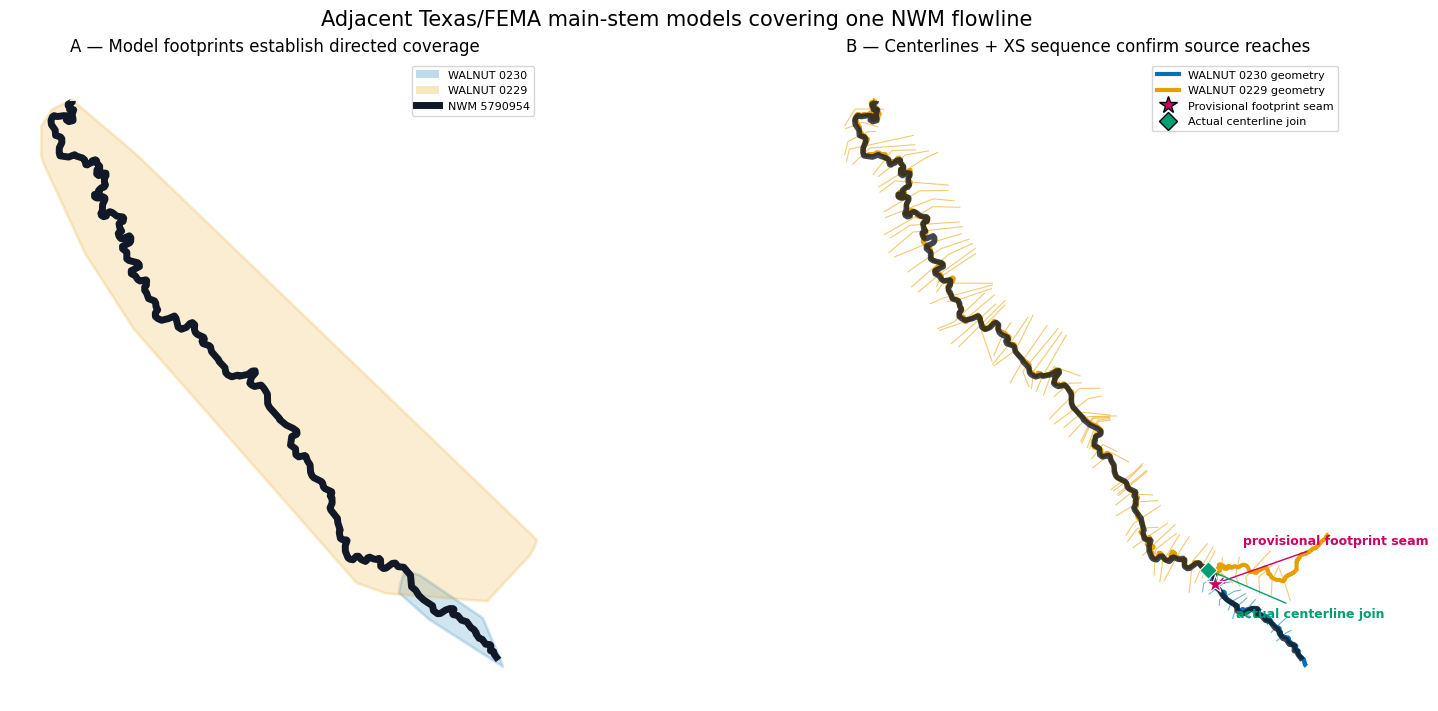

H:\Symphony\ras-commander\multi-model-breakout\examples\assets\236_multi_model_1d_breakout_planning\01_extent_and_geometry_confirmation.png


In [4]:
colors = {
    "WALNUT 0230": "#0072B2",
    "WALNUT 0229": "#E69F00",
}
edge_geometry = target_edge.geometry.iloc[0]
seam = plan.seams_df.iloc[0]
focus = edge_geometry.buffer(1400.0)

confirmed = plan.reach_assignments_df.loc[
    plan.reach_assignments_df["status"] == "confirmed"
]
confirmed_reach_ids = set(confirmed["reach_id"])
confirmed_centerlines = catalog.centerlines_gdf.loc[
    catalog.centerlines_gdf["reach_id"].isin(confirmed_reach_ids)
]
confirmed_xs = catalog.cross_sections_gdf.loc[
    catalog.cross_sections_gdf["reach_id"].isin(confirmed_reach_ids)
    & catalog.cross_sections_gdf.intersects(focus)
]
centerline_by_source = confirmed.set_index("geometry_id").geometry
centerline_join = centerline_by_source.loc[SOURCE_IDS[0]].intersection(
    centerline_by_source.loc[SOURCE_IDS[1]]
)
assert centerline_join.geom_type == "Point"
edge_join_point, _ = nearest_points(edge_geometry, centerline_join)
join_measure = float(edge_geometry.project(edge_join_point))

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
for source_id in SOURCE_IDS:
    footprint = catalog.footprints_gdf.loc[
        catalog.footprints_gdf["geometry_id"] == source_id
    ]
    footprint.plot(
        ax=axes[0], color=colors[source_id], edgecolor=colors[source_id],
        alpha=0.18, linewidth=2,
    )
target_edge.plot(ax=axes[0], color="#111827", linewidth=5)

for source_id in SOURCE_IDS:
    confirmed_centerlines.loc[
        confirmed_centerlines["geometry_id"] == source_id
    ].plot(ax=axes[1], color=colors[source_id], linewidth=3)
    confirmed_xs.loc[
        confirmed_xs["geometry_id"] == source_id
    ].plot(ax=axes[1], color=colors[source_id], linewidth=0.8, alpha=0.55)
target_edge.plot(ax=axes[1], color="#111827", linewidth=4, alpha=0.8)
plan.seams_df.plot(
    ax=axes[1], color="#CC0066", marker="*", markersize=180,
    edgecolor="white", linewidth=0.8, zorder=10,
)
gpd.GeoSeries([centerline_join], crs=PROJECT_CRS).plot(
    ax=axes[1], color="#009E73", marker="D", markersize=80,
    edgecolor="white", linewidth=0.8, zorder=11,
)

for ax in axes:
    xmin, ymin, xmax, ymax = focus.bounds
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
    ax.set_axis_off()
axes[0].set_title("A — Model footprints establish directed coverage")
axes[1].set_title("B — Centerlines + XS sequence confirm source reaches")
axes[1].annotate(
    "provisional footprint seam",
    (seam.geometry.x, seam.geometry.y),
    xytext=(20, 28), textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "#CC0066"},
    color="#CC0066", fontsize=9, fontweight="bold",
)
axes[1].annotate(
    "actual centerline join",
    (centerline_join.x, centerline_join.y),
    xytext=(20, -34), textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "#009E73"},
    color="#009E73", fontsize=9, fontweight="bold",
)
axes[0].legend(
    handles=[
        Patch(facecolor=colors[source_id], alpha=0.25, label=source_id)
        for source_id in SOURCE_IDS
    ] + [Line2D([0], [0], color="#111827", linewidth=5, label=f"NWM {TARGET_EDGE_ID}")],
    loc="best", fontsize=8,
)
axes[1].legend(
    handles=[
        Line2D([0], [0], color=colors[source_id], linewidth=3, label=f"{source_id} geometry")
        for source_id in SOURCE_IDS
    ] + [
        Line2D([0], [0], marker="*", color="none", markerfacecolor="#CC0066", markersize=13, label="Provisional footprint seam"),
        Line2D([0], [0], marker="D", color="none", markerfacecolor="#009E73", markersize=9, label="Actual centerline join"),
    ],
    loc="best", fontsize=8,
)
fig.suptitle("Adjacent Texas/FEMA main-stem models covering one NWM flowline", fontsize=15)
figure_1 = ASSET_ROOT / "01_extent_and_geometry_confirmation.png"
fig.savefig(figure_1, dpi=180, bbox_inches="tight")
plt.show()
print(figure_1)


![Real Texas/FEMA source footprints and hydraulic geometry confirmation](assets/236_multi_model_1d_breakout_planning/01_extent_and_geometry_confirmation.png)

## 4. Visual proof: the minimum-switch coverage chain

The upper ribbons show where each footprint covers the NWM edge. Their 1,006-ft
shared interval is a handoff search zone—not a reason to score seven unrelated
signals. The lower ribbon is the deterministic ownership plan: upstream source
until the midpoint, downstream source afterward. No coverage gap is hidden.


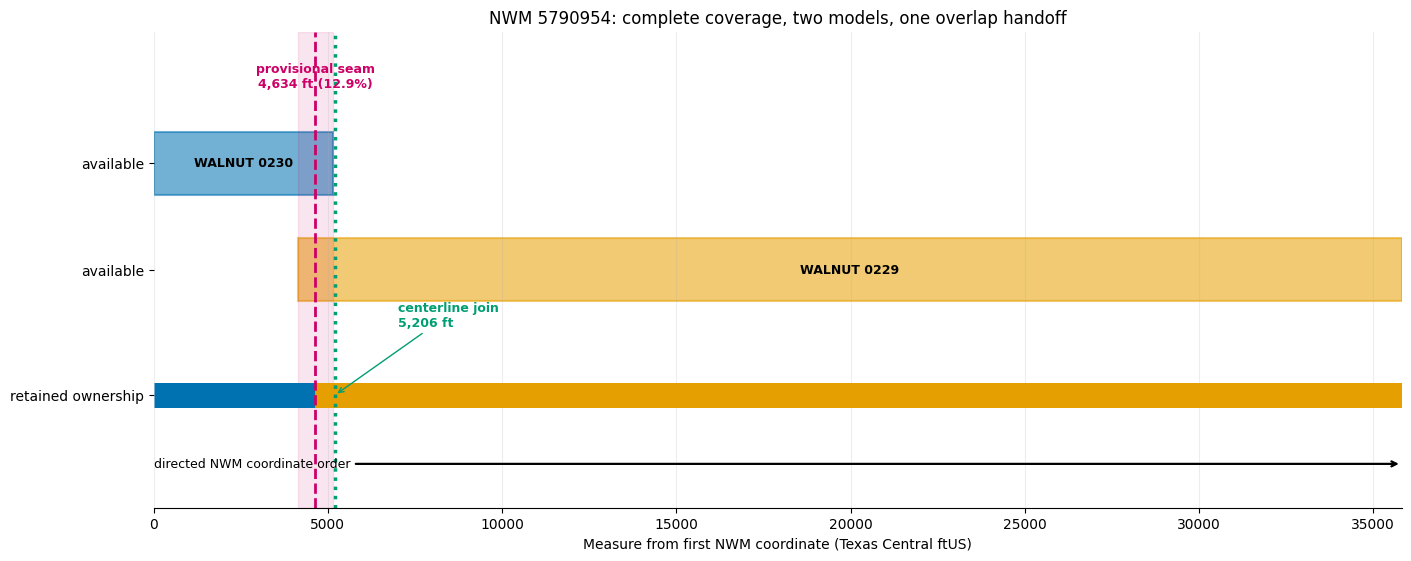

H:\Symphony\ras-commander\multi-model-breakout\examples\assets\236_multi_model_1d_breakout_planning\02_directed_coverage_chain.png


In [5]:
parts = plan.edge_coverage.coverage_parts_df.sort_values("coverage_start")
slices = plan.source_slices_df.sort_values("source_order")
edge_length = float(plan_row["edge_length"])
seam_measure = float(seam["seam_measure"])

fig, ax = plt.subplots(figsize=(14, 5.5), constrained_layout=True)
source_y = {SOURCE_IDS[0]: 2.2, SOURCE_IDS[1]: 1.35}
for row in parts.itertuples(index=False):
    ax.add_patch(Rectangle(
        (row.coverage_start, source_y[row.geometry_id] - 0.25),
        row.coverage_end - row.coverage_start, 0.5,
        facecolor=colors[row.geometry_id], alpha=0.55,
        edgecolor=colors[row.geometry_id], linewidth=1.5,
    ))
    ax.text(
        (row.coverage_start + row.coverage_end) / 2,
        source_y[row.geometry_id], row.geometry_id,
        ha="center", va="center", fontsize=9, fontweight="bold",
    )

overlap_start = float(seam["overlap_start"])
overlap_end = float(seam["overlap_end"])
ax.axvspan(overlap_start, overlap_end, color="#CC0066", alpha=0.10)
for row in slices.itertuples(index=False):
    ax.plot(
        [row.retained_start, row.retained_end], [0.35, 0.35],
        color=colors[row.geometry_id], linewidth=18, solid_capstyle="butt",
    )
ax.axvline(seam_measure, color="#CC0066", linestyle="--", linewidth=2)
ax.axvline(join_measure, color="#009E73", linestyle=":", linewidth=2.5)
ax.text(
    seam_measure, 2.78,
    f"provisional seam\n{seam_measure:,.0f} ft ({seam.seam_fraction:.1%})",
    ha="center", va="bottom", color="#CC0066", fontsize=9, fontweight="bold",
)
ax.annotate(
    f"centerline join\n{join_measure:,.0f} ft",
    xy=(join_measure, 0.35), xytext=(join_measure + 1800, 0.9),
    arrowprops={"arrowstyle": "->", "color": "#009E73"},
    color="#009E73", fontsize=9, fontweight="bold",
)
ax.annotate(
    "directed NWM coordinate order",
    xy=(edge_length, -0.2), xytext=(0, -0.2),
    arrowprops={"arrowstyle": "->", "linewidth": 1.6},
    va="center", fontsize=9,
)
ax.set_xlim(0, edge_length)
ax.set_ylim(-0.55, 3.25)
ax.set_yticks([2.2, 1.35, 0.35])
ax.set_yticklabels(["available", "available", "retained ownership"])
ax.set_xlabel("Measure from first NWM coordinate (Texas Central ftUS)")
ax.set_title(
    f"NWM {TARGET_EDGE_ID}: complete coverage, two models, one overlap handoff"
)
ax.grid(axis="x", alpha=0.22)
for side in ("left", "right", "top"):
    ax.spines[side].set_visible(False)
figure_2 = ASSET_ROOT / "02_directed_coverage_chain.png"
fig.savefig(figure_2, dpi=180, bbox_inches="tight")
plt.show()
print(figure_2)


![Directed model coverage intervals and provisional handoff](assets/236_multi_model_1d_breakout_planning/02_directed_coverage_chain.png)

## 5. Visual proof: a clean main-stem handoff

This final map projects directly intersecting cross sections onto the NWM edge.
The actual centerline intersection lies between the last upstream-model cross
section and the first downstream-model cross section. No source cross section
intersects both centerlines, and the two source cross-section sets do not cross
one another. That is the adjacent-main-stem condition needed for the writer.


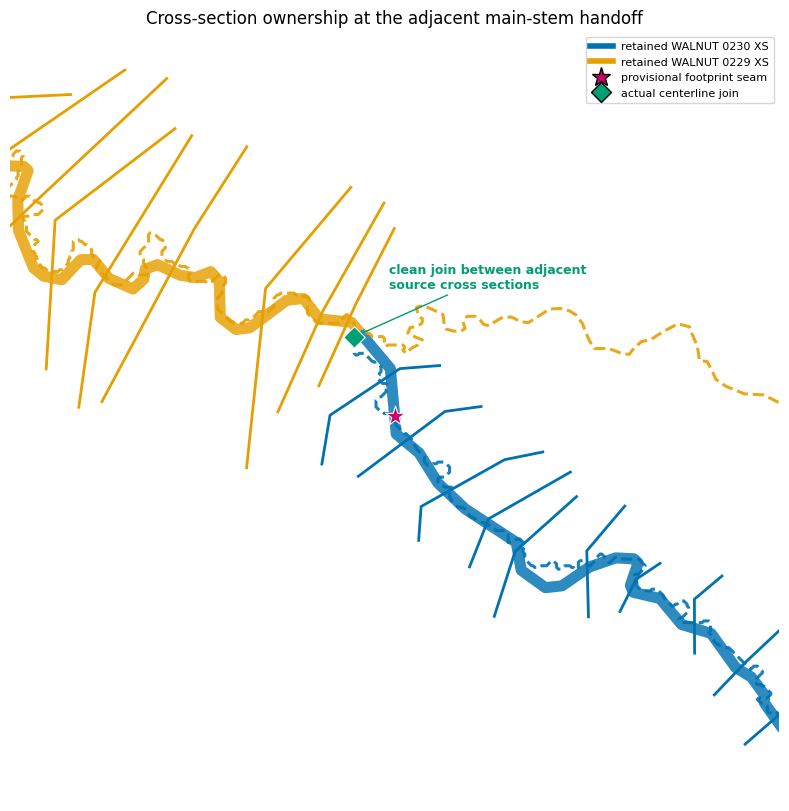

,geometry_id,station,edge_measure,retained_side
8,WALNUT 0230,5159,1203,True
7,WALNUT 0230,4510,1583,True
5,WALNUT 0230,4041,1959,True
4,WALNUT 0230,3396,2431,True
3,WALNUT 0230,2815,2919,True
2,WALNUT 0230,2199,3506,True
1,WALNUT 0230,1880,3758,True
0,WALNUT 0230,1522,4062,True
9,WALNUT 0230,918,4460,True
6,WALNUT 0230,405,4884,True


Centerline join measure: 5,206 ft
Cross sections intersecting both centerlines: 0
Pairwise source cross-section intersections: 0
H:\Symphony\ras-commander\multi-model-breakout\examples\assets\236_multi_model_1d_breakout_planning\03_cross_section_ownership.png


In [6]:
assignment_by_source = confirmed.set_index("geometry_id")
xs_measure_rows = []
source_xs_by_id = {}
for source_id in SOURCE_IDS:
    reach_id = assignment_by_source.loc[source_id, "reach_id"]
    all_source_xs = catalog.cross_sections_gdf.loc[
        catalog.cross_sections_gdf["reach_id"] == reach_id
    ].copy()
    source_xs_by_id[source_id] = all_source_xs
    source_xs = all_source_xs.loc[
        all_source_xs.intersects(edge_geometry)
    ].copy()
    for row in source_xs.itertuples(index=False):
        edge_point, _ = nearest_points(edge_geometry, row.geometry)
        measure = float(edge_geometry.project(edge_point))
        retained = (
            measure <= join_measure
            if source_id == SOURCE_IDS[0]
            else measure >= join_measure
        )
        xs_measure_rows.append({
            "geometry_id": source_id,
            "station": row.station,
            "edge_measure": measure,
            "retained_side": retained,
            "geometry": row.geometry,
        })
xs_ownership = gpd.GeoDataFrame(
    xs_measure_rows, geometry="geometry", crs=PROJECT_CRS
).sort_values(["edge_measure", "geometry_id"])
pairwise_xs_intersections = sum(
    int(source_xs_by_id[SOURCE_IDS[1]].intersects(xs_geometry).sum())
    for xs_geometry in source_xs_by_id[SOURCE_IDS[0]].geometry
)
assert pairwise_xs_intersections == 0

fig, ax = plt.subplots(figsize=(12.5, 8), constrained_layout=True)
actual_ownership = (
    (SOURCE_IDS[0], substring(edge_geometry, 0.0, join_measure)),
    (SOURCE_IDS[1], substring(edge_geometry, join_measure, edge_geometry.length)),
)
for source_id, geometry in actual_ownership:
    gpd.GeoSeries([geometry], crs=PROJECT_CRS).plot(
        ax=ax, color=colors[source_id], linewidth=8, alpha=0.82,
    )
for source_id in SOURCE_IDS:
    centerline = confirmed_centerlines.loc[
        confirmed_centerlines["geometry_id"] == source_id
    ]
    centerline.plot(
        ax=ax, color=colors[source_id], linewidth=2.2, linestyle="--", alpha=0.9,
    )
    xs_ownership.loc[
        (xs_ownership["geometry_id"] == source_id)
        & xs_ownership["retained_side"]
    ].plot(ax=ax, color=colors[source_id], linewidth=2.0)
excluded_xs = xs_ownership.loc[~xs_ownership["retained_side"]]
if not excluded_xs.empty:
    excluded_xs.plot(
        ax=ax, color="#6B7280", linewidth=1.4, linestyle=":", alpha=0.9,
    )
plan.seams_df.plot(
    ax=ax, color="#CC0066", marker="*", markersize=220,
    edgecolor="white", linewidth=0.8, zorder=10,
)
gpd.GeoSeries([centerline_join], crs=PROJECT_CRS).plot(
    ax=ax, color="#009E73", marker="D", markersize=120,
    edgecolor="white", linewidth=0.8, zorder=11,
)
seam_focus = seam.geometry.buffer(2300.0)
xmin, ymin, xmax, ymax = seam_focus.bounds
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
ax.set_axis_off()
ax.set_title("Cross-section ownership at the adjacent main-stem handoff")
ax.legend(
    handles=[
        Line2D([0], [0], color=colors[SOURCE_IDS[0]], linewidth=4, label=f"retained {SOURCE_IDS[0]} XS"),
        Line2D([0], [0], color=colors[SOURCE_IDS[1]], linewidth=4, label=f"retained {SOURCE_IDS[1]} XS"),
        Line2D([0], [0], marker="*", color="none", markerfacecolor="#CC0066", markersize=14, label="provisional footprint seam"),
        Line2D([0], [0], marker="D", color="none", markerfacecolor="#009E73", markersize=10, label="actual centerline join"),
    ],
    loc="best", fontsize=8,
)
ax.annotate(
    "clean join between adjacent\nsource cross sections",
    (centerline_join.x, centerline_join.y),
    xytext=(25, 35), textcoords="offset points",
    arrowprops={"arrowstyle": "->", "color": "#009E73"},
    color="#009E73", fontsize=9, fontweight="bold",
)
figure_3 = ASSET_ROOT / "03_cross_section_ownership.png"
fig.savefig(figure_3, dpi=180, bbox_inches="tight")
plt.show()

display(
    xs_ownership.drop(columns="geometry").style.format({"edge_measure": "{:.0f}"})
)
print(f"Centerline join measure: {join_measure:,.0f} ft")
print(f"Cross sections intersecting both centerlines: {int(plan.handoff_diagnostics_df.iloc[0]['cross_centerline_xs_count'])}")
print(f"Pairwise source cross-section intersections: {pairwise_xs_intersections}")
print(figure_3)


## 6. Visual proof: reach-length evidence before geometry assembly

Channel and overbank distances answer different questions. The channel audit
compares each stored channel length with the distance between adjacent cut-line
intersections measured along the RAS river polyline. The overbank panel shows
whether stored LOB/ROB values already carry routing evidence distinct from the
channel. Neither check changes the FEMA sources.

These legacy text geometries contain no compiled geometry HDF, so they cannot
yet prove that regenerated RAS Mapper flow paths reproduce the stored values.
That test belongs on the provisional joined geometry and is shown after the
figure.


,geometry_id,channel_intervals,max_channel_error_percent,channel_all_within_1pct,stored_overbanks_distinct,compiled_geometry_hdf_exists,flow_path_preflight
0,WALNUT 0230,9,0.120%,True,False,False,clone_and_regenerate_required
1,WALNUT 0229,75,1.815%,False,False,False,clone_and_regenerate_required


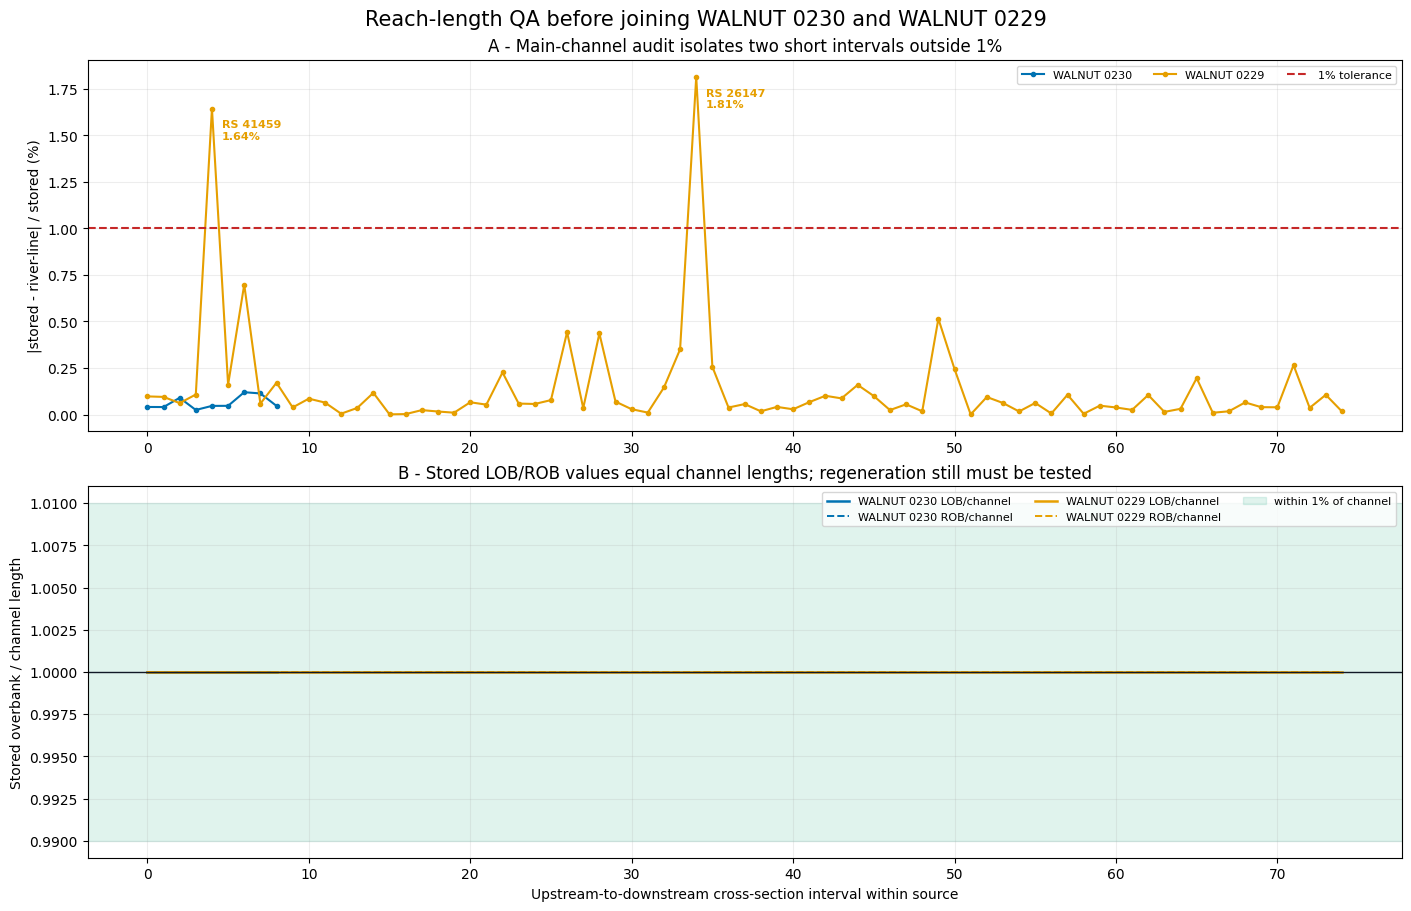

H:\Symphony\ras-commander\multi-model-breakout\examples\assets\236_multi_model_1d_breakout_planning\04_reach_length_policy_evidence.png


In [7]:
channel_frames = []
overbank_frames = []
policy_rows = []
model_paths = catalog.models_df.set_index("geometry_id")["geometry_path"]

for source_id in SOURCE_IDS:
    geometry_path = Path(model_paths.loc[source_id])
    channel = RasGeometryCompute.audit_main_channel_lengths(
        geometry_path, tolerance_fraction=0.01
    ).copy()
    channel["geometry_id"] = source_id
    channel["interval_order"] = range(len(channel))
    channel_frames.append(channel)

    stored = GeomCrossSection.get_cross_sections(geometry_path)
    stored = stored.loc[stored["Type"] == 1].copy()
    usable = stored["Length_Channel"].abs() > 1.0e-9
    stored = stored.loc[usable].copy()
    stored["geometry_id"] = source_id
    stored["interval_order"] = range(len(stored))
    stored["left_channel_ratio"] = (
        stored["Length_Left"] / stored["Length_Channel"]
    )
    stored["right_channel_ratio"] = (
        stored["Length_Right"] / stored["Length_Channel"]
    )
    overbank_frames.append(stored)

    overbanks_distinct = bool(
        ((stored["left_channel_ratio"] - 1.0).abs() > 0.01).any()
        or ((stored["right_channel_ratio"] - 1.0).abs() > 0.01).any()
    )
    compiled_hdf = Path(f"{geometry_path}.hdf")
    preflight = (
        "preserve_and_recompute_only_at_join_boundary"
        if not compiled_hdf.is_file() and overbanks_distinct
        else "clone_and_regenerate_required"
    )
    usable_channel = channel.loc[~channel["reach_end"]]
    policy_rows.append({
        "geometry_id": source_id,
        "channel_intervals": len(usable_channel),
        "max_channel_error_percent": 100.0 * usable_channel["relative_error_channel"].max(),
        "channel_all_within_1pct": not usable_channel["main_channel_flagged"].any(),
        "stored_overbanks_distinct": overbanks_distinct,
        "compiled_geometry_hdf_exists": compiled_hdf.is_file(),
        "flow_path_preflight": preflight,
    })

channel_evidence = pd.concat(channel_frames, ignore_index=True)
overbank_evidence = pd.concat(overbank_frames, ignore_index=True)
policy_preflight = pd.DataFrame(policy_rows)
display(policy_preflight.style.format({"max_channel_error_percent": "{:.3f}%"}))

fig, axes = plt.subplots(2, 1, figsize=(14, 9), constrained_layout=True)
for source_id in SOURCE_IDS:
    channel = channel_evidence.loc[
        (channel_evidence["geometry_id"] == source_id)
        & ~channel_evidence["reach_end"]
    ]
    axes[0].plot(
        channel["interval_order"],
        100.0 * channel["relative_error_channel"],
        marker="o", markersize=3, linewidth=1.5,
        color=colors[source_id], label=source_id,
    )
    for flagged in channel.loc[channel["main_channel_flagged"]].itertuples(index=False):
        error_percent = 100.0 * flagged.relative_error_channel
        axes[0].annotate(
            f"RS {flagged.RS}\n{error_percent:.2f}%",
            (flagged.interval_order, error_percent),
            xytext=(7, -8), textcoords="offset points", va="top",
            color=colors[source_id], fontsize=8, fontweight="bold",
        )
    overbank = overbank_evidence.loc[
        overbank_evidence["geometry_id"] == source_id
    ]
    axes[1].plot(
        overbank["interval_order"], overbank["left_channel_ratio"],
        color=colors[source_id], linewidth=1.8, label=f"{source_id} LOB/channel",
    )
    axes[1].plot(
        overbank["interval_order"], overbank["right_channel_ratio"],
        color=colors[source_id], linewidth=1.4, linestyle="--",
        label=f"{source_id} ROB/channel",
    )

axes[0].axhline(1.0, color="#C62828", linestyle="--", linewidth=1.5, label="1% tolerance")
axes[0].set_ylabel("|stored - river-line| / stored (%)")
axes[0].set_title("A - Main-channel audit isolates two short intervals outside 1%")
axes[0].legend(fontsize=8, ncol=3)
axes[0].grid(alpha=0.22)

axes[1].axhspan(0.99, 1.01, color="#009E73", alpha=0.12, label="within 1% of channel")
axes[1].axhline(1.0, color="#111827", linewidth=1.0)
axes[1].set_xlabel("Upstream-to-downstream cross-section interval within source")
axes[1].set_ylabel("Stored overbank / channel length")
axes[1].set_title("B - Stored LOB/ROB values equal channel lengths; regeneration still must be tested")
axes[1].legend(fontsize=8, ncol=3)
axes[1].grid(alpha=0.22)
fig.suptitle("Reach-length QA before joining WALNUT 0230 and WALNUT 0229", fontsize=15)
figure_4 = ASSET_ROOT / "04_reach_length_policy_evidence.png"
fig.savefig(figure_4, dpi=180, bbox_inches="tight")
plt.show()
print(figure_4)


![Main-channel and overbank reach-length evidence](assets/236_multi_model_1d_breakout_planning/04_reach_length_policy_evidence.png)

The river-polyline audit validates 82 of 84 usable channel intervals within
1%. Two short `WALNUT 0229` intervals are flagged at 1.64% and 1.81%; those
are explicit centerline QA findings for review, not an overbank-policy trigger.
Both models store LOB and ROB
lengths equal to channel length and have no compiled geometry HDF, so this
preflight does **not** guess a final flow-path policy. After the assembler
writes and compiles its provisional geometry, the complete check is:

```python
policy = RasGeometryCompute.assess_flow_path_policy(
    provisional_geom_hdf,
    tolerance_fraction=0.01,
    join_upstream_xs=(joined_river, joined_reach, upstream_join_rs),
    join_downstream_xs=(joined_river, joined_reach, downstream_join_rs),
    review_segments_path=WORK_ROOT / "join_flow_path_segments.parquet",
)
```

The method clones the whole project internally, regenerates RAS Mapper flow
paths, recomputes LOB/ROB lengths, and recommends
`regenerate_and_recompute` only if every usable interval reproduces its stored
value within 1%. Otherwise it recommends
`preserve_and_recompute_only_at_join_boundary`; only the new join interval is
measured from regenerated paths, and the two clipped LOB/ROB segments are
retained as
reviewable GeoParquet evidence. Channel flags remain informative QA and never
change the overbank policy.



![Cross-section ownership around the provisional source handoff](assets/236_multi_model_1d_breakout_planning/03_cross_section_ownership.png)

## 7. Write the provisional multi-source geometry

The same public plan now feeds `assemble_network_edge()`. The writer uses the
actual centerline intersection, retains only each source's continuous owned
slice, rejects cross-source cut-line intersections, and creates a new `.prj`,
`.p01`, `.g01`, and `.f01`. It never modifies either FEMA source.

Because the NWM feature reaches both available outer source termini, the
requested automatic 10% upstream and 25% downstream hydraulic buffers are
constrained by available geometry in this case. The result attributes record
both requested and actually applied distances. The strict inundation flag also
records whether its requested one-section downstream overlap was available.


In [8]:
ASSEMBLY_ROOT = WORK_ROOT / "assembled_provisional"
if ASSEMBLY_ROOT.exists():
    raise FileExistsError(
        f"{ASSEMBLY_ROOT} already exists. Remove this generated working folder before rerunning."
    )

assembled = RasBreakout1D.assemble_network_edge(
    source_models,
    catalog,
    plan,
    ASSEMBLY_ROOT,
    destination_name=f"NWM_{TARGET_EDGE_ID}_breakout",
    destination_river=f"NWM {TARGET_EDGE_ID}",
    destination_reach="Main",
    inundation_overlap_xs=1,
)

station_map_path = WORK_ROOT / "assembly_station_map.parquet"
seams_path = WORK_ROOT / "assembly_seams.parquet"
assembled.station_map_gdf.to_parquet(station_map_path, index=False)
assembled.seams_gdf.to_parquet(seams_path, index=False)

assert assembled.validation.is_valid
assert len(assembled.station_map_gdf.query("source_node_type == 1")) == 72
assert assembled.seams_gdf.iloc[0]["join_method"] == "centerline_intersection"
assert not assembled.reach_lengths_finalized
assembled_channel_audit = RasGeometryCompute.audit_main_channel_lengths(
    assembled.geometry_file, tolerance_fraction=0.01
)
assert not assembled_channel_audit.loc[~assembled_channel_audit["reach_end"], "main_channel_flagged"].any()

display(assembled.validation.checks_df)
display(assembled.seams_gdf.drop(columns="geometry"))
display(pd.DataFrame([assembled.station_map_gdf.attrs]))
display(assembled_channel_audit[["RS", "len_channel_stored", "len_channel_recomputed", "relative_error_channel", "main_channel_flagged"]].tail())
print(f"Independent project: {assembled.project_file}")
print(f"Station provenance: {station_map_path}")
print(f"Resolved seam evidence: {seams_path}")


2026-09-08 14:41:47 - ras_commander.RasMap - WARNING - RASMapper file not found: H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\assembled_provisional\NWM_5790954_breakout.rasmap


2026-09-08 14:41:47 - ras_commander.RasBreakout1D - INFO - Assembled H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\assembled_provisional\NWM_5790954_breakout.prj from 2 source models with 72 retained cross sections


,check,severity,passed,detail
0,retained_cross_sections,ERROR,True,expected=72 actual=72
1,restationed_cross_sections,ERROR,True,"expected=('41332.705', '40683.968', '40215.156..."
2,restationed_nodes,ERROR,True,all cross sections and structures retain order...
3,node_payload_content,ERROR,True,every retained node payload matches its source...
4,station_order,ERROR,True,destination river stations strictly decrease d...
5,single_reach,ERROR,True,"destination reaches=[{'River': 'NWM 5790954', ..."
6,reach_lengths,ERROR,True,destination LOB/channel/ROB lengths match the ...
7,steady_flow_reach,ERROR,True,"flow-change reaches=[('NWM 5790954', 'Main')]"
8,steady_profiles,ERROR,True,"expected=('10-year', '25-year', '50-year', '1p..."
9,steady_boundaries,ERROR,True,"boundary reaches=[('NWM 5790954', 'Main')]"


,edge_id,seam_index,upstream_geometry_id,downstream_geometry_id,join_method,connector_length,edge_measure,upstream_source_measure,downstream_source_measure,upstream_source_station,downstream_source_station,upstream_destination_station,downstream_destination_station,join_left_length,join_channel_length,join_right_length,length_policy
0,5790954,0,WALNUT 0230,WALNUT 0229,centerline_intersection,0.0,5205.799664,6853.731957,6300.56737,405,36772,36579.172,36038.507,540.664972,540.664972,540.664972,provisional_join_channel_fallback


,edge_id,edge_length,main_channel_length,joined_centerline_length,upstream_buffer_distance,downstream_buffer_distance,upstream_buffer_applied,downstream_buffer_applied,inundation_overlap_xs,inundation_overlap_xs_applied,flow_path_policy,reach_lengths_finalized
0,5790954,35819.279831,41332.704538,41334.704538,4133.270454,10333.176135,0.0,0.0,1,0,preserve_and_recompute_only_at_join_boundary,False


,RS,len_channel_stored,len_channel_recomputed,relative_error_channel,main_channel_flagged
67,3746.45,307.815,307.815106,3.440478e-07,False
68,3438.635,780.720,780.719934,8.482563e-08,False
69,2657.915,427.547,427.547183,4.286929e-07,False
70,2230.368,2230.368,2230.368265,1.189591e-07,False
71,0,0.000,NaN,NaN,False


Independent project: H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\assembled_provisional\NWM_5790954_breakout.prj
Station provenance: H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\assembly_station_map.parquet
Resolved seam evidence: H:\Symphony\ras-commander\multi-model-breakout\working\236_multi_model_1d_breakout_planning\assembly_seams.parquet


## 8. Visual proof: written geometry, retained blocks, and restationing

Panel A reads the river line back from the written HEC-RAS geometry. Gray cut
lines are available source sections; colored cut lines are the 72 sections
actually written. The black overlay is the strict raster-export selection.
Panel B proves that source-local station systems were replaced by one continuous
distance-from-downstream-terminus system while source provenance remains visible.


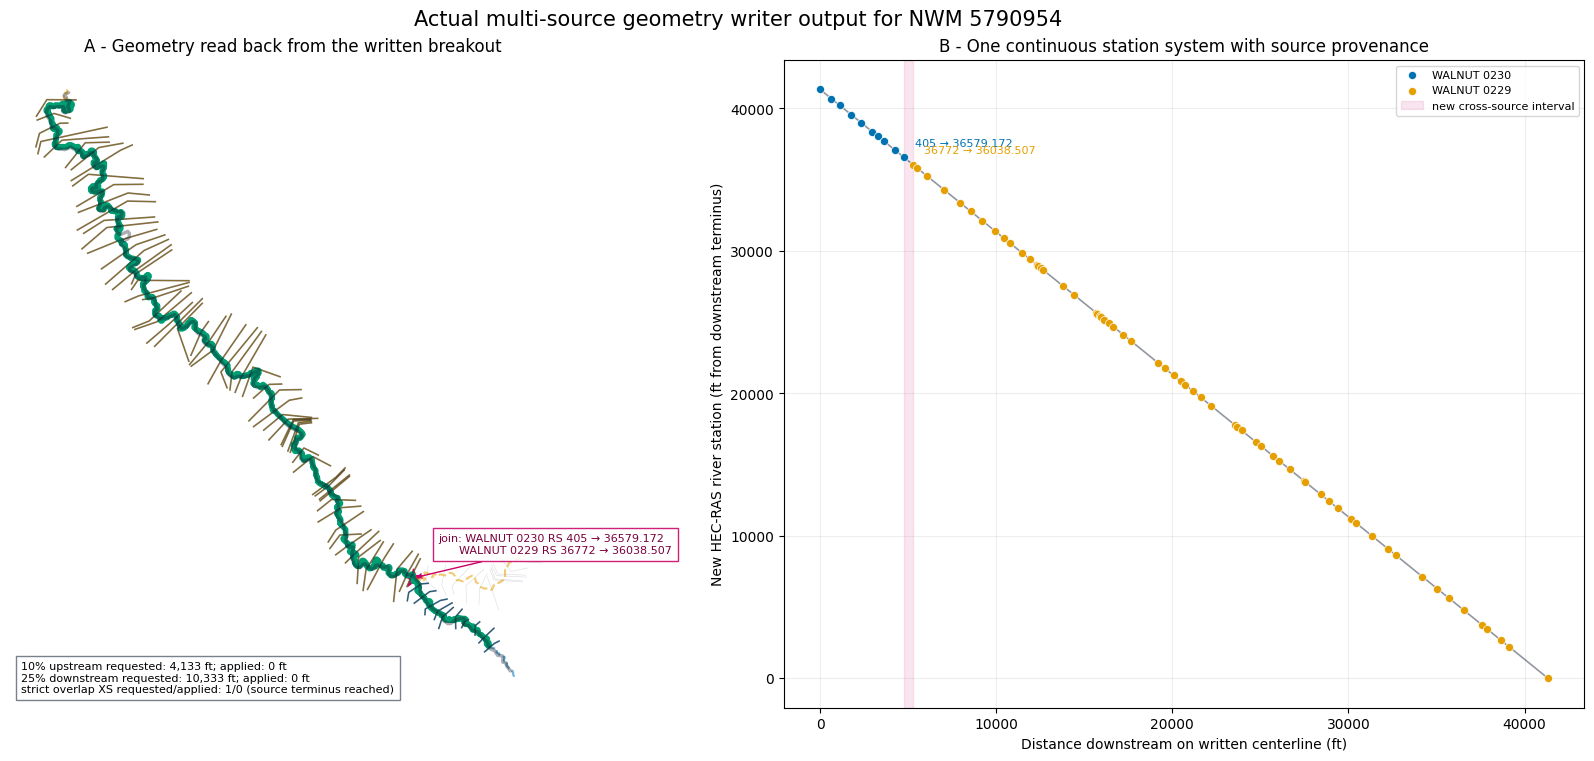

H:\Symphony\ras-commander\multi-model-breakout\examples\assets\236_multi_model_1d_breakout_planning\05_written_geometry_and_restationing.png


In [9]:
written_centerline = GeomParser.get_river_centerlines(assembled.geometry_file).geometry.iloc[0]
node_map = assembled.station_map_gdf.copy()
written_xs = node_map.loc[node_map["source_node_type"] == 1].copy()
strict_xs = written_xs.loc[written_xs["in_inundation_domain"]]
all_selected_source_xs = catalog.cross_sections_gdf.loc[
    catalog.cross_sections_gdf["reach_id"].isin(confirmed_reach_ids)
]
join_evidence = assembled.seams_gdf.iloc[0]
join_upstream = written_xs.loc[written_xs["is_join_upstream"]].iloc[0]
join_downstream = written_xs.loc[written_xs["is_join_downstream"]].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(17, 7.5), constrained_layout=True)
all_selected_source_xs.plot(ax=axes[0], color="#9CA3AF", linewidth=0.45, alpha=0.35)
for source_id in SOURCE_IDS:
    confirmed_centerlines.loc[
        confirmed_centerlines["geometry_id"] == source_id
    ].plot(ax=axes[0], color=colors[source_id], linewidth=1.5, linestyle="--", alpha=0.55)
    written_xs.loc[
        written_xs["source_geometry_id"] == source_id
    ].plot(ax=axes[0], color=colors[source_id], linewidth=0.85, alpha=0.75)
gpd.GeoSeries([written_centerline], crs=PROJECT_CRS).plot(
    ax=axes[0], color="#009E73", linewidth=4, label="written joined centerline"
)
strict_xs.plot(ax=axes[0], color="#111827", linewidth=1.25, alpha=0.45)
target_edge.plot(ax=axes[0], color="#111827", linewidth=2.5, alpha=0.35)
assembled.seams_gdf.plot(ax=axes[0], color="#CC0066", marker="*", markersize=180)
axes[0].annotate(
    f"join: {join_upstream.source_geometry_id} RS {join_upstream.source_station} → {join_upstream.destination_station}\n"
    f"      {join_downstream.source_geometry_id} RS {join_downstream.source_station} → {join_downstream.destination_station}",
    xy=(join_evidence.geometry.x, join_evidence.geometry.y), xytext=(18, 18),
    textcoords="offset points", arrowprops={"arrowstyle": "->", "color": "#CC0066"},
    fontsize=8, color="#7A003C", bbox={"facecolor": "white", "alpha": 0.88, "edgecolor": "#CC0066"},
)
axes[0].set_title("A - Geometry read back from the written breakout")
domain_attrs = assembled.station_map_gdf.attrs
axes[0].text(
    0.02, 0.02,
    f"10% upstream requested: {domain_attrs['upstream_buffer_distance']:,.0f} ft; applied: {domain_attrs['upstream_buffer_applied']:,.0f} ft\n"
    f"25% downstream requested: {domain_attrs['downstream_buffer_distance']:,.0f} ft; applied: {domain_attrs['downstream_buffer_applied']:,.0f} ft\n"
    f"strict overlap XS requested/applied: {domain_attrs['inundation_overlap_xs']}/{domain_attrs['inundation_overlap_xs_applied']} (source terminus reached)",
    transform=axes[0].transAxes, fontsize=8, va="bottom",
    bbox={"facecolor": "white", "alpha": 0.9, "edgecolor": "#6B7280"},
)
axes[0].set_axis_off()

for source_id in SOURCE_IDS:
    frame = written_xs.loc[written_xs["source_geometry_id"] == source_id]
    axes[1].scatter(
        frame["centerline_measure"], frame["destination_station"].astype(float),
        s=34, color=colors[source_id], edgecolor="white", linewidth=0.5, label=source_id, zorder=3,
    )
axes[1].plot(
    written_xs["centerline_measure"], written_xs["destination_station"].astype(float),
    color="#374151", linewidth=1.2, alpha=0.55,
)
for row in (join_upstream, join_downstream):
    axes[1].annotate(
        f"{row.source_station} → {row.destination_station}",
        (row.centerline_measure, float(row.destination_station)),
        xytext=(8, 8), textcoords="offset points", fontsize=8, color=colors[row.source_geometry_id],
    )
axes[1].axvspan(
    join_upstream.centerline_measure, join_downstream.centerline_measure,
    color="#CC0066", alpha=0.10, label="new cross-source interval",
)
axes[1].set_xlabel("Distance downstream on written centerline (ft)")
axes[1].set_ylabel("New HEC-RAS river station (ft from downstream terminus)")
axes[1].set_title("B - One continuous station system with source provenance")
axes[1].grid(alpha=0.22)
axes[1].legend(fontsize=8)
fig.suptitle("Actual multi-source geometry writer output for NWM 5790954", fontsize=15)
figure_5 = ASSET_ROOT / "05_written_geometry_and_restationing.png"
fig.savefig(figure_5, dpi=180, bbox_inches="tight")
plt.show()
print(figure_5)


![Written multi-source geometry and continuous restationing](assets/236_multi_model_1d_breakout_planning/05_written_geometry_and_restationing.png)

## Result and hydraulic finalization gate

The independent provisional project contains 72 cross sections: all 10 owned
sections from `WALNUT 0230` and 62 non-overlapping downstream sections from
`WALNUT 0229`. Fourteen downstream-source sections upstream of the accepted join
are excluded. The retained cross-section main-channel span is 41,333 ft, destination stations run
continuously from 41,332.705 to 0, and the new join interval is 540.665 ft. All
geometry-node payload hashes, flow profiles, rewritten flow locations, endpoint
boundaries, project relationships, and source immutability checks pass.

The result is deliberately marked `reach_lengths_finalized=False`: source LOB/ROB
values are preserved within each model, while the new join uses its channel
length provisionally. Compile this geometry with a supported modern HEC-RAS, run
`assess_flow_path_policy()` using the two join stations in `seams_gdf`, and pass
the returned evidence as `flow_path_policy_results={0: policy}` to a second
`assemble_network_edge()` destination. That final write either applies regenerated
LOB/ROB lengths everywhere after the 1% match, or preserves source values and
applies only the two clipped join-segment lengths.

Notebook 235 remains the executable source-versus-breakout run/result-comparison
reference. This notebook now supplies the missing multi-model writer, station map,
and visual geometry proof; numerical source-result comparison follows after the
modern compiled-HDF flow-path gate.
